# HAR TFM

In [6]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns

import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics


ruta_archivo_csv = "../../Procesamiento Datos/Dataset/HAR_TFM.csv.gz"

df = pd.read_csv(ruta_archivo_csv)
print(df)


              Ax        Ay        Az       Gx        Gy        Gz          Mx  \
0       0.028037  0.272983  0.938547 -0.85745  1.530512 -1.285625   16.856251   
1       0.036297 -1.118226 -0.264005 -0.61710  0.379362 -0.267025  362.943756   
2       0.032427  0.145508  1.354897 -1.07635 -1.441825  0.696025    0.356250   
3       0.370183  0.204207  0.954832 -0.37954 -0.559665 -0.238312  -25.068750   
4       1.329001 -0.985352  0.107682  1.72095 -1.653575 -1.253725  -39.600002   
...          ...       ...       ...      ...       ...       ...         ...   
365995  0.177876  0.465430  0.859490 -0.09094  0.068109  0.005574  -19.800001   
365996  0.351190 -0.832287 -0.448884 -0.00990 -0.000825  0.009762   32.812500   
365997  1.014918 -0.141639  0.255638  0.01265  0.007700  0.000137    3.187500   
365998  1.009626 -0.294183 -0.150097  0.02640  0.024750  0.030938   36.000000   
365999  0.230048 -0.802216 -0.552589 -0.00770 -0.023100 -0.003025  -15.356251   

               My         M

# Modelo de red neuronal

In [7]:
features = ['Az', 'AyGx','AxGx','AyGy','AxGy','AzGx','Mxz','MyGx','AyMz','Ayz','Mz','Ax','My','Gzy','Ay','MxGx','MxGy','Myz','Mx','Mxy','AyMx','AzMx','AyMy','Gz']

# Verificar duplicados
duplicates = set(x for x in features if features.count(x) > 1)

if duplicates:
    print(f"\nSe encontraron elementos duplicados: {list(duplicates)}")
else:
    print("\nNo hay elementos duplicados.")


No hay elementos duplicados.


In [8]:
import joblib

# Guardar los nombres de las columnas
columnas_guardadas = df[features].columns.tolist()
ruta_columnas = "../../Datos/Columnas/columnas_HAR_UPM_LSTM.pkl"
joblib.dump(columnas_guardadas, ruta_columnas)

['../../Datos/Columnas/columnas_HAR_UPM_LSTM.pkl']

In [9]:
#Para ver la mayor corelación
#features = ['AyGx', 'AyGy', 'Myz', 'Ayz', 'Mxy', 'Gzy', 'AyMz', 'MyGy', 'AyMy', 'MyGx', 'Mxz', 'AxMy', 'Az', 'Mx', 'AxGx', 'Mz', 'AxGy', 'MxGx', 'AzGx']
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 366000
Número de columnas: 24


In [10]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout
import time


# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = df[features]
y = df['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
#model.add(LSTM(256, input_shape=(1, X_train.shape[2])))
#model.add(Dropout(0.2))
#model.add(Dense(6, activation='softmax'))
#--------------------------------------------
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))
model.add(LSTM(128))
#model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
#--------------------------------------------
#model.add(LSTM(128, input_shape=(1, X_train.shape[2])))
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(LSTM(128))
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense
#model.add(Dense(6, activation='softmax'))
#------------------------------------------------
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la primera capa LSTM
#model.add(LSTM(128))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la segunda capa LSTM
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la otra capa Dense adicional
#model.add(Dense(6, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Inicio del entrenamiento
inicio = time.time()
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))
# Fin del entrenamiento
fin = time.time()

tiempo_entrenamiento = fin - inicio


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Epoch 1/20
4575/4575 [==============================] - 44s 9ms/step - loss: 0.6966 - accuracy: 0.7489 - val_loss: 0.5610 - val_accuracy: 0.8022
Epoch 2/20
4575/4575 [==============================] - 42s 9ms/step - loss: 0.5123 - accuracy: 0.8174 - val_loss: 0.4760 - val_accuracy: 0.8300
Epoch 3/20
4575/4575 [==============================] - 40s 9ms/step - loss: 0.4480 - accuracy: 0.8411 - val_loss: 0.4352 - val_accuracy: 0.8454
Epoch 4/20
4575/4575 [==============================] - 39s 9ms/step - loss: 0.4122 - accuracy: 0.8537 - val_loss: 0.4068 - val_accuracy: 0.8569
Epoch 5/20
4575/4575 [==============================] - 40s 9ms/step - loss: 0.3842 - accuracy: 0.8636 - val_loss: 0.3763 - val_accuracy: 0.8671
Epoch 6/20
4575/4575 [==============================] - 39s 9ms/step - loss: 0.3635 - accuracy: 0.8708 - val_loss: 0.3637 - val_accuracy: 0.8702
Epoch 7/20
4575/4575 [==============================] - 39s 9ms/step - loss: 0.3449 - accuracy: 0.8773 - val_loss: 0.3511 - val_ac

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

print(f"Tiempo de entrenamiento del LSTM: {tiempo_entrenamiento/60:.2f} minutos")

2288/2288 [==============================] - 8s 3ms/step
Accuracy: 0.9013661202185792
Precision: 0.9048515789092576
Recall: 0.9013661202185792
F1 Score: 0.9018951612357821
Tiempo de entrenamiento del LSTM: 13.34 minutos


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

2288/2288 [==============================] - 7s 3ms/step


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Label: 1, Caminar
Accuracy: 0.940724043715847
Precision: 0.8604693635284449
Recall: 0.7702305051495831
F1 Score: 0.8128531378046151

Label: 2, Metro
Accuracy: 0.9769262295081967
Precision: 0.9438836612489307
Recall: 0.9143946299825971
F1 Score: 0.9289051647935345

Label: 3, Bus
Accuracy: 0.9800546448087432
Precision: 0.9476348547717842
Recall: 0.9323154800783802
F1 Score: 0.9399127500205777

Label: 4, Conducir coche
Accuracy: 0.9917349726775956
Precision: 0.9687650554038864
Recall: 0.9824118557120756
F1 Score: 0.9755407317566201

Label: 5, Subir o bajar escaleras
Accuracy: 0.9317213114754098
Precision: 0.7547838412473423
Recall: 0.8738103052182474
F1 Score: 0.8099475245265799

Label: 6, Estar detenido
Accuracy: 0.9815710382513662
Precision: 0.9534533277521976
Recall: 0.9349039566573634
F1 Score: 0.9440875367845154



## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

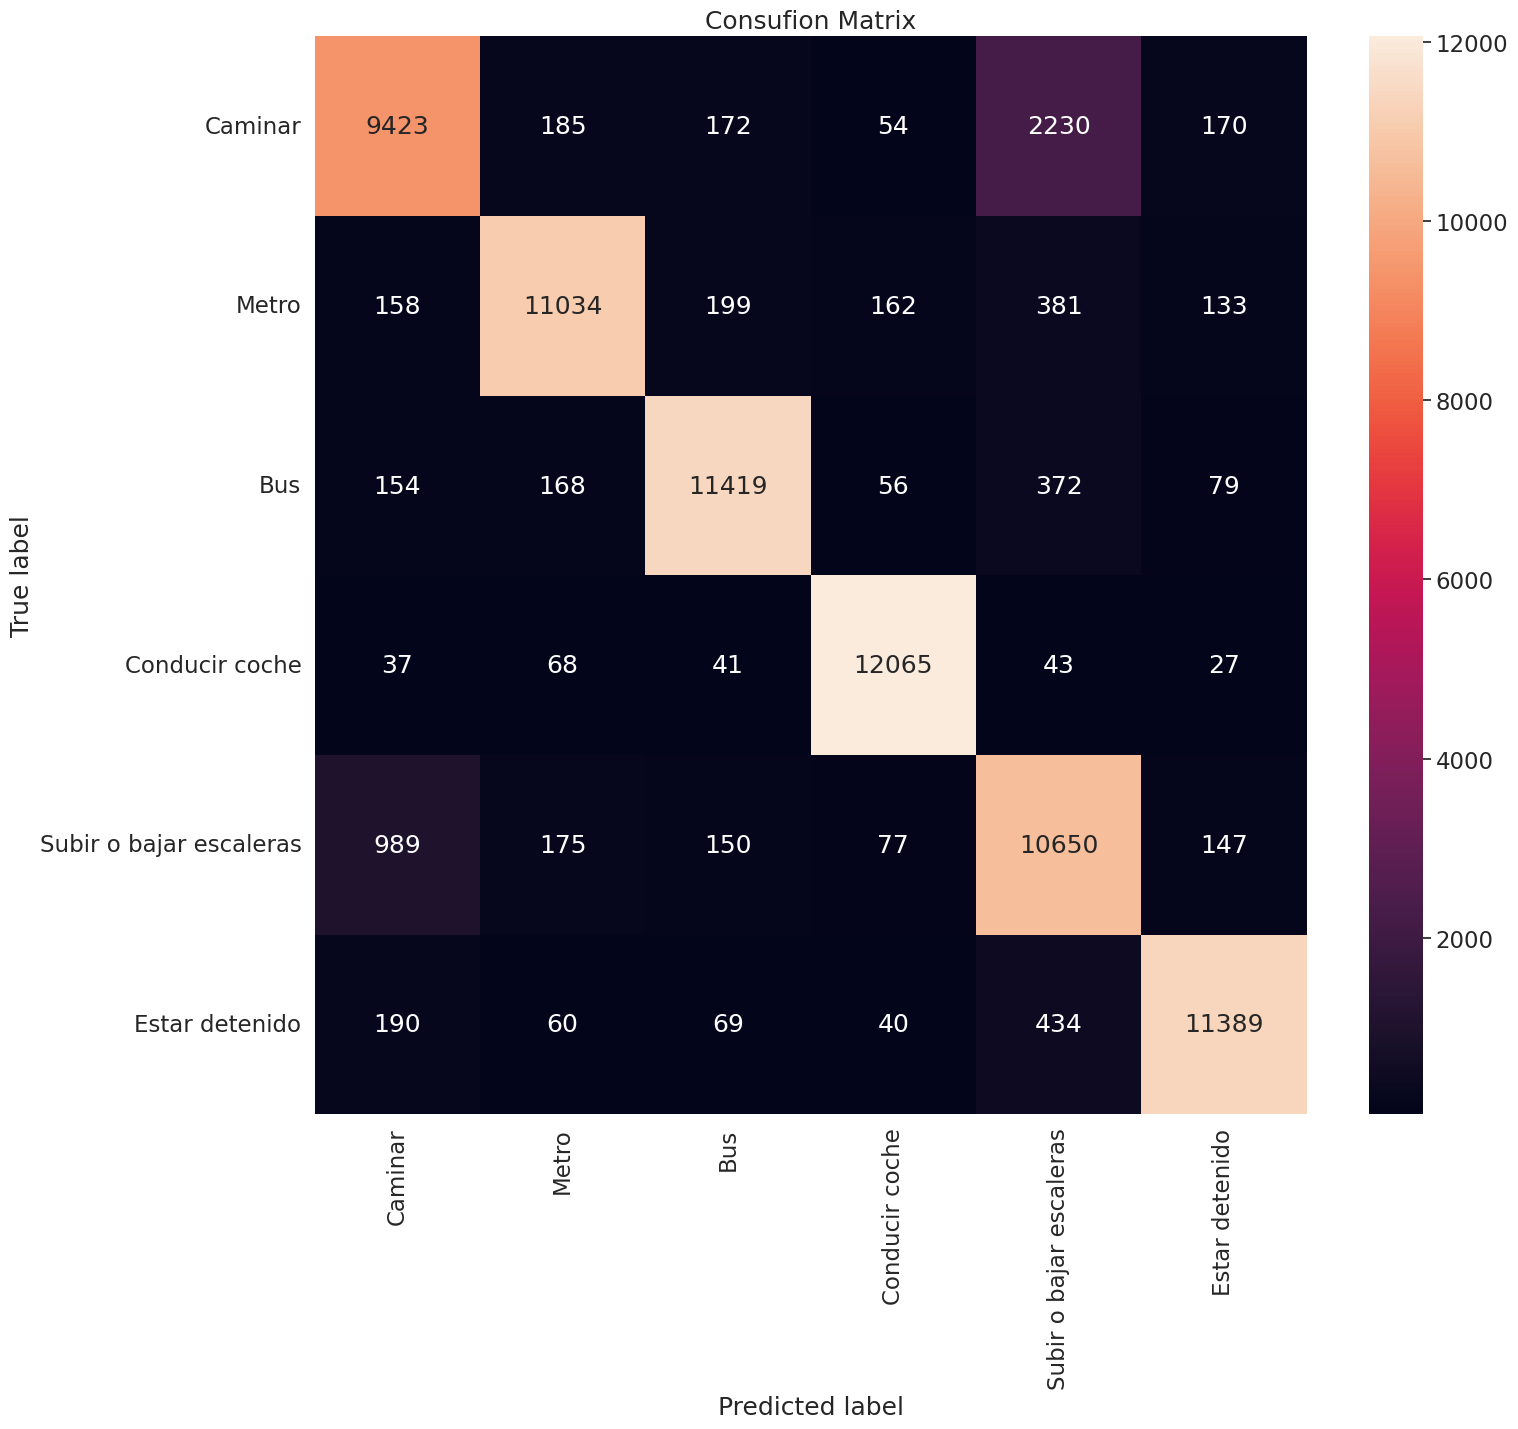

In [13]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

#Labels=['Caminar', 'Metro', 'Conducir coche', 'Subir o bajar escaleras']
#Labels=['Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
#Labels=['Metro', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [14]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 12234, Actividad: Caminar
Valor: 1, Cantidad: 12067, Actividad: Metro
Valor: 2, Cantidad: 12248, Actividad: Bus
Valor: 3, Cantidad: 12281, Actividad: Conducir coche
Valor: 4, Cantidad: 12188, Actividad: Subir o bajar escaleras
Valor: 5, Cantidad: 12182, Actividad: Estar detenido


# Exportamos el modelo

In [15]:
model.save('../../Datos/Modelos/model.h5')

/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [16]:
import joblib
# Ruta donde se guardará la información del modelo
ruta_info_modelo = "../../Datos/Info/info_modelo_HAR_UPM_LSTM.pkl"
info_modelo = {
    'columnas': columnas_guardadas,
    'input_names': model.input_names,
    'output_names': model.output_names
}
joblib.dump(info_modelo, ruta_info_modelo)

# Ruta donde se guardará el modelo
ruta_modelo = "../../Datos/Modelos/model_HAR_UPM_LSTM"
model.save(ruta_modelo)

# Ruta donde se guardará el LabelEncoder
ruta_label_encoder = "../../Datos/Label/label_encoder_HAR_UPM_LSTM.pkl"
joblib.dump(label_encoder, ruta_label_encoder)


INFO:tensorflow:Assets written to: ../../Datos/Modelos/model_HAR_UPM_LSTM/assets


INFO:tensorflow:Assets written to: ../../Datos/Modelos/model_HAR_UPM_LSTM/assets


['../../Datos/Label/label_encoder_HAR_UPM_LSTM.pkl']